In [1]:
from function_ei import (
    generate_random_graph,
    random_probability_vector,
    simulate_many_runs,
    simulate_many_runs_degree
)

Grid (T, edge_prob):   0%|          | 0/15351 [00:00<?, ?cell/s]

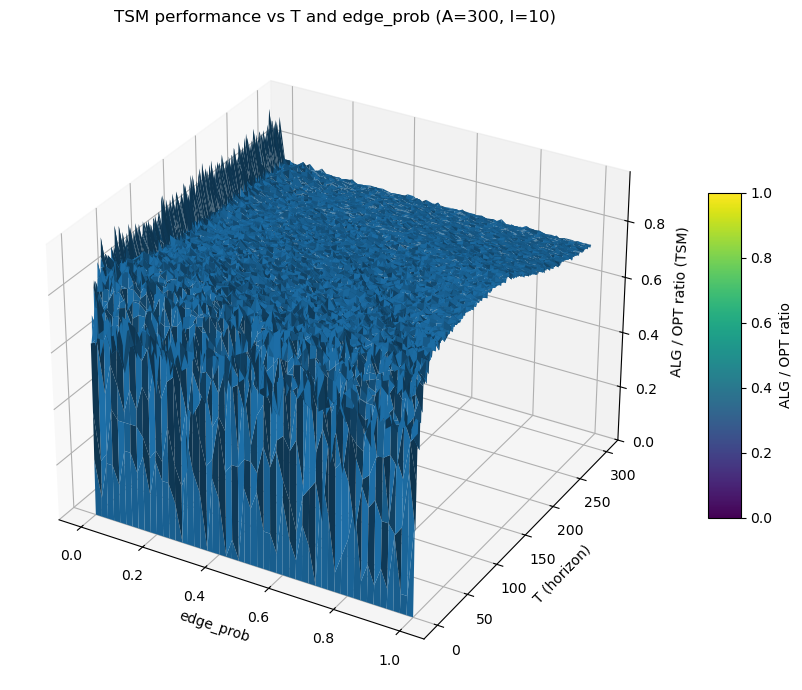

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 仅用于注册 3D projection
from tqdm.auto import tqdm  # ✅ 进度条（VSCode/Jupyter友好）

A_size = 300
I_size = 10

Ts = np.arange(0, 301, 1)
edge_probs = np.linspace(0, 1, 51)

num_graphs_per_cell = 5
runs_per_graph = 3

T_grid, EP_grid = np.meshgrid(Ts, edge_probs, indexing='ij')
Z = np.zeros_like(T_grid, dtype=float)

total_cells = len(Ts) * len(edge_probs)
pbar_cells = tqdm(total=total_cells, desc="Grid (T, edge_prob)", unit="cell")

for i_T, T in enumerate(Ts):
    for j_ep, edge_prob in enumerate(edge_probs):

        if T == 0:
            Z[i_T, j_ep] = 0.0
            pbar_cells.update(1)
            continue

        ratios = []
        # ✅ 每个 cell 内也给个小进度（可选）
        for _ in range(num_graphs_per_cell):
            neighbors = generate_random_graph(A_size, I_size, edge_prob)
            p = random_probability_vector(I_size)

            avg_ratio_tsm, _ = simulate_many_runs(
                A_size, I_size, neighbors, p, T, num_runs=runs_per_graph
            )
            ratios.append(avg_ratio_tsm)

        Z[i_T, j_ep] = float(np.mean(ratios))
        pbar_cells.update(1)

pbar_cells.close()

# ========== 3D Plot ==========
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(EP_grid, T_grid, Z,
rstride=1, cstride=1,
linewidth=0, antialiased=True)

ax.set_xlabel("edge_prob")
ax.set_ylabel("T (horizon)")
ax.set_zlabel("ALG / OPT ratio (TSM)")
ax.set_title("TSM performance vs T and edge_prob (A=300, I=10)")
ax.set_zlim(bottom=0)

fig.colorbar(surf, shrink=0.5, aspect=10, label="ALG / OPT ratio")
plt.tight_layout()
plt.show()